In [32]:
import pandas as pd
import requests
import os
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import numpy as np
import matplotlib as plt


In [ ]:
kaggle_df = pd.read_csv('data/cbb.csv')
kaggle_df.head()


## DO NOT RUN CELL BELOW AGAIN!!

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time

YEARS = [y for y in range(2015, 2026) if y != 2020]  # 2005–2025, no 2020
SLEEP_SECONDS = 3

CONFERENCES = {
    "big-12":      "Big 12",
    "big-ten":     "Big Ten",
    "wcc":         "West Coast",
    "sec":         "SEC",
    "big-east":    "Big East",
    "mac":         "Mid-American",
    "mvc":         "Missouri Valley",
    "atlantic-10": "Atlantic 10",
    "american":    "American",
    "acc":         "ACC",
}

HEADERS = {"User-Agent": "Mozilla/5.0 (research project; contact: you@email.com)"}
BASE_URL = "https://www.sports-reference.com/cbb/conferences/{conf}/men/{year}.html"

all_rows = []

for conf_slug, conf_name in CONFERENCES.items():
    for year in YEARS:
        url = BASE_URL.format(conf=conf_slug, year=year)
        print(f"Fetching {conf_name} {year} ... ", end="", flush=True)

        try:
            resp = requests.get(url, headers=HEADERS, timeout=15)
            if resp.status_code != 200:
                print(f"SKIP (HTTP {resp.status_code})")
                time.sleep(SLEEP_SECONDS)
                continue

            soup = BeautifulSoup(resp.text, "html.parser")

            # Primary: look for id="conference_stats"
            table = soup.find("table", {"id": "conference_stats"})

            if table is None:
                for t in soup.find_all("table"):
                    caption = t.find("caption")
                    if caption and "school" in caption.get_text(strip=True).lower():
                        table = t
                        break

            if table is None:
                print("SKIP (table not found)")
                time.sleep(SLEEP_SECONDS)
                continue

            thead = table.find("thead")
            header_rows = thead.find_all("tr") if thead else []
            cols = []
            if header_rows:
                for th in header_rows[-1].find_all(["th", "td"]):
                    cols.append(th.get_text(strip=True))

            tbody = table.find("tbody")
            rows = tbody.find_all("tr") if tbody else table.find_all("tr")[len(header_rows):]

            row_count = 0
            for tr in rows:
                if "thead" in tr.get("class", []):  # skip mid-table header rows
                    continue

                cells = tr.find_all(["th", "td"])
                if not cells:
                    continue

                values = [c.get_text(strip=True) for c in cells]
                row_dict = dict(zip(cols, values)) if cols else {f"col_{i}": v for i, v in enumerate(values)}

                # Skip blank/header ghost rows
                school = row_dict.get("School", row_dict.get("col_1", "")).strip()
                if not school or school.lower() == "school":
                    continue

                row_dict["conference"] = conf_name
                row_dict["year"] = year
                all_rows.append(row_dict)
                row_count += 1

            print(f"OK ({row_count} teams)")

        except Exception as e:
            print(f"ERROR: {e}")

        time.sleep(SLEEP_SECONDS)

df = pd.DataFrame(all_rows)

meta_cols = ["year", "conference"]
other_cols = [c for c in df.columns if c not in meta_cols]
df = df[meta_cols + other_cols]

# Coerce numeric columns
for col in df.columns:
    if col not in ("School", "conference"):
        df[col] = pd.to_numeric(df[col], errors="ignore")



Fetching Big 12 2015 ... OK (10 teams)
Fetching Big 12 2016 ... OK (10 teams)
Fetching Big 12 2017 ... OK (10 teams)
Fetching Big 12 2018 ... OK (10 teams)
Fetching Big 12 2019 ... OK (10 teams)
Fetching Big 12 2021 ... OK (10 teams)
Fetching Big 12 2022 ... OK (10 teams)
Fetching Big 12 2023 ... OK (10 teams)
Fetching Big 12 2024 ... OK (14 teams)
Fetching Big 12 2025 ... OK (16 teams)
Fetching Big Ten 2015 ... OK (14 teams)
Fetching Big Ten 2016 ... OK (14 teams)
Fetching Big Ten 2017 ... OK (14 teams)
Fetching Big Ten 2018 ... OK (14 teams)
Fetching Big Ten 2019 ... OK (14 teams)
Fetching Big Ten 2021 ... OK (14 teams)
Fetching Big Ten 2022 ... OK (14 teams)
Fetching Big Ten 2023 ... OK (14 teams)
Fetching Big Ten 2024 ... OK (14 teams)
Fetching Big Ten 2025 ... OK (18 teams)
Fetching West Coast 2015 ... OK (10 teams)
Fetching West Coast 2016 ... OK (10 teams)
Fetching West Coast 2017 ... OK (10 teams)
Fetching West Coast 2018 ... OK (10 teams)
Fetching West Coast 2019 ... OK (10 te

/var/folders/4f/vb0mn9ss4yz07crx77ny47680000gn/T/ipykernel_62035/4240097015.py:111: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors="ignore")


In [43]:
display(df.head(10))

,year,conference,Rk,School,G,W,L,W%,,ORtg,...,TRB,AST,STL,BLK,TOV,PF,PTS,SRS,SOS,Pace
0,2015,Big 12,1,Kansas,36,5,6,0.750,NaN,106.3,...,37.9,13.2,6.6,4.9,12.9,17.8,64.8,18.47,12.13,66.7
1,2015,Big 12,2,Iowa State,34,6,5,0.735,NaN,111.4,...,35.9,16.1,6.4,3.9,11.0,15.5,69.0,17.94,9.15,69.8
2,2015,Big 12,3,Oklahoma,35,5,6,0.686,NaN,105.2,...,38.1,12.3,6.8,5.0,12.0,16.3,62.7,18.65,9.94,67.4
3,2015,Big 12,4,Baylor,34,6,5,0.706,NaN,109.2,...,39.2,14.6,7.7,3.9,12.8,16.6,60.2,17.85,9.33,62.8
4,2015,Big 12,5,West Virginia,35,5,5,0.714,NaN,104.9,...,36.3,14.1,10.7,2.7,12.9,23.5,66.8,15.12,9.29,68.7
5,2015,Big 12,6,Kansas State,32,1,10,0.469,NaN,99.5,...,31.7,13.0,6.1,2.3,13.3,20.0,63.8,8.48,9.29,63.1
6,2015,Big 12,7,Oklahoma State,32,3,8,0.563,NaN,103.6,...,32.5,11.4,7.9,4.9,12.3,19.2,62.8,12.95,9.63,64.6
7,2015,Big 12,8,Texas,34,4,7,0.588,NaN,105.9,...,39.7,13.0,3.8,7.8,12.8,16.3,60.3,16.16,9.07,62.9
8,2015,Big 12,9,TCU,33,2,8,0.545,NaN,104.6,...,36.8,13.2,6.3,5.3,12.0,20.6,62.4,11.10,5.32,64.7
9,2015,Big 12,10,Texas Tech,32,0,10,0.406,NaN,95.9,...,33.5,11.1,5.8,4.1,13.8,17.4,64.3,3.77,7.20,63.0


In [ ]:
df.to_csv("cbb_conference_stats.csv", index=False)
print("Saved to cbb_conference_stats.csv")

💾 Saved to cbb_conference_stats.csv


In [45]:
print(df.columns)

Index(['year', 'conference', 'Rk', 'School', 'G', 'W', 'L', 'W%', '', 'ORtg',
       'DRtg', 'NRtg', 'FG', 'FGA', 'FG%', '3P', '3PA', '3P%', 'eFG%', 'FT',
       'FTA', 'FT%', 'ORB', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS',
       'SRS', 'SOS', 'Pace'],
      dtype='object')


In [52]:
print(kaggle_df.columns)

Index(['TEAM', 'CONF', 'G', 'W', 'ADJOE', 'ADJDE', 'BARTHAG', 'EFG_O', 'EFG_D',
       'TOR', 'TORD', 'ORB', 'DRB', 'FTR', 'FTRD', '2P_O', '2P_D', '3P_O',
       '3P_D', 'ADJ_T', 'WAB', 'POSTSEASON', 'SEED', 'YEAR'],
      dtype='object')


In [ ]:
df = pd.read_csv('data/cbb_conference_stats.csv')

df['School_clean'] = df['School'].str.strip().str.lower()
kaggle_df['TEAM_clean'] = kaggle_df['TEAM'].str.strip().str.lower()

merged_df = pd.merge(
    df,
    kaggle_df,
    left_on=['School_clean', 'year'],
    right_on=['TEAM_clean', 'YEAR'],
    how='inner'
)

# Binary target variable: Final Four or better
merged_df['final_four'] = merged_df['POSTSEASON'].isin(
    ['F4', '2ND', 'Champions']
).astype(int)

# Binary target: made tournament at all
merged_df['made_tourney'] = merged_df['POSTSEASON'].notna().astype(int)

print(f"Merged shape: {merged_df.shape}")
print(f"Final Four+ teams: {merged_df['final_four'].sum()}")

Merged shape: (876, 61)
Final Four+ teams: 25


In [67]:
cols_to_drop = [
    'G_y',          # duplicate of G_x (games played)
    'W_y',          # duplicate of W_x (wins)
    'ORB_y',        # keep ORB_x (per game from scrape) OR ORB_y (rate from kaggle)
    'YEAR',         # duplicate of year
    'TEAM',         # duplicate of School
    'TEAM_clean',   # duplicate of School_clean
    'CONF',         # duplicate of conference
    'Unnamed: 8' , # blank column from scrape
]

merged_df = merged_df.drop(columns=cols_to_drop)

# Also clean up the _x suffixes now that duplicates are gone
merged_df = merged_df.rename(columns={
    'G_x':   'G',
    'W_x':   'W',
    'ORB_x': 'ORB',
})

print(merged_df.columns)

Index(['year', 'conference', 'Rk', 'School', 'G', 'W', 'L', 'W%', 'ORtg',
       'DRtg', 'NRtg', 'FG', 'FGA', 'FG%', '3P', '3PA', '3P%', 'eFG%', 'FT',
       'FTA', 'FT%', 'ORB', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS',
       'SRS', 'SOS', 'Pace', 'School_clean', 'ADJOE', 'ADJDE', 'BARTHAG',
       'EFG_O', 'EFG_D', 'TOR', 'TORD', 'DRB', 'FTR', 'FTRD', '2P_O', '2P_D',
       '3P_O', '3P_D', 'ADJ_T', 'WAB', 'POSTSEASON', 'SEED', 'final_four',
       'made_tourney'],
      dtype='object')


ROC-AUC Score: 0.977
                             Label  Coefficient
     Adjusted Offensive Efficiency     1.630765
              Strength of Schedule     1.188927
Championship Probability (BARTHAG)     1.064432
            Defensive Rebound Rate     0.980435
            3-Point Rate - Offense     0.671184
           Effective FG% - Offense     0.512927
    Turnover Rate Forced - Defense     0.292124
            Offensive Rebound Rate     0.192477
         Free Throw Rate - Offense     0.072454
   Effective FG% Allowed - Defense     0.065444
 Free Throw Rate Allowed - Defense     0.044264
             Adjusted Tempo (Pace)    -0.094082
                 Wins Above Bubble    -0.149617
    3-Point Rate Allowed - Defense    -0.766076
           Turnover Rate - Offense    -0.897616
     Adjusted Defensive Efficiency    -2.257017


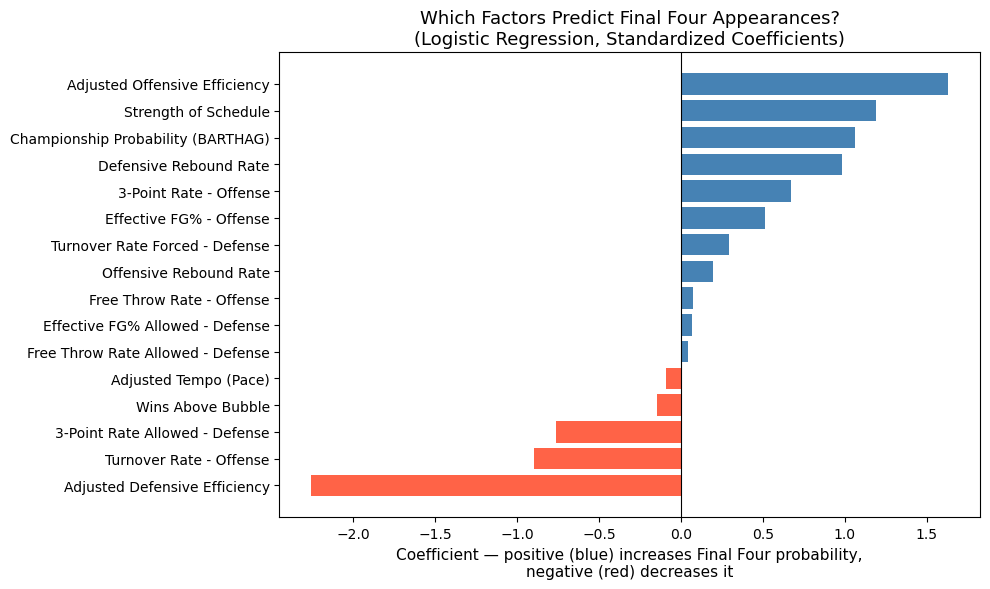

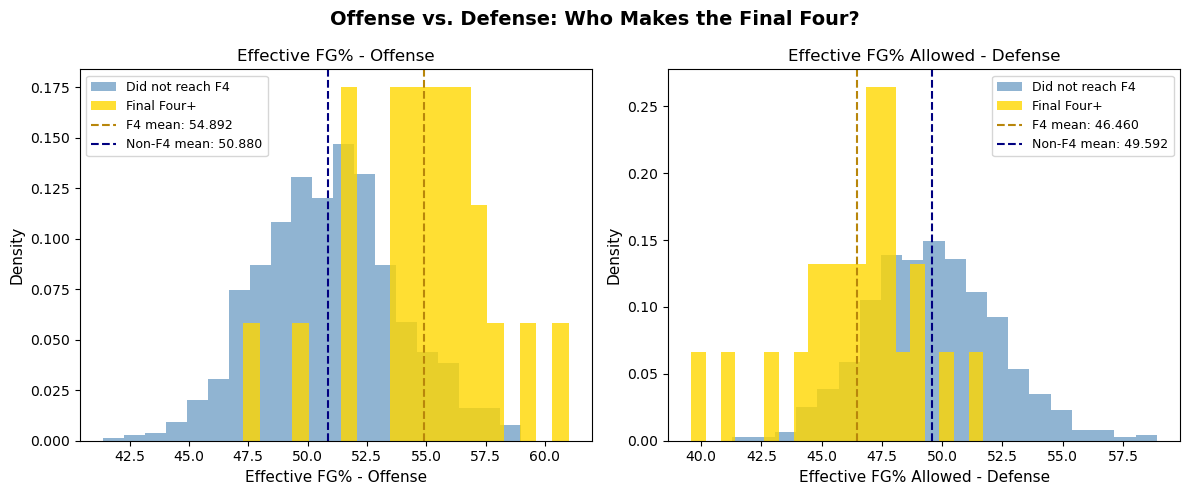

In [ ]:

#  QUESTION 1: Which factors best predict Final Four?

# Feature column names and their human-readable labels
feature_meta = {
    'ADJOE':    'Adjusted Offensive Efficiency',
    'ADJDE':    'Adjusted Defensive Efficiency',
    'BARTHAG':  'Championship Probability (BARTHAG)',
    'EFG_O':    'Effective FG% - Offense',
    'EFG_D':    'Effective FG% Allowed - Defense',
    'TOR':      'Turnover Rate - Offense',
    'TORD':     'Turnover Rate Forced - Defense',
    'ORB':      'Offensive Rebound Rate',
    'DRB':      'Defensive Rebound Rate',
    'FTR':      'Free Throw Rate - Offense',
    'FTRD':     'Free Throw Rate Allowed - Defense',
    '3P_O':     '3-Point Rate - Offense',
    '3P_D':     '3-Point Rate Allowed - Defense',
    'ADJ_T':    'Adjusted Tempo (Pace)',
    'WAB':      'Wins Above Bubble',
    'SOS':      'Strength of Schedule',
}

features = list(feature_meta.keys())
labels   = list(feature_meta.values())
target   = 'final_four'

# Drop rows with missing values in features or target
model_df = merged_df[features + [target]].dropna()

X = model_df[features]
y = model_df[target]

# Scale features so coefficients are directly comparable across variables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Logistic regression — class_weight='balanced' corrects for imbalance
lr = LogisticRegression(max_iter=1000, class_weight='balanced')
lr.fit(X_scaled, y)

# Build results dataframe with readable labels
coef_df = pd.DataFrame({
    'Feature':     features,
    'Label':       labels,
    'Coefficient': lr.coef_[0]
}).sort_values('Coefficient', ascending=False)

#  Plot 
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['steelblue' if c > 0 else 'tomato' for c in coef_df['Coefficient']]
ax.barh(coef_df['Label'], coef_df['Coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)

ax.set_xlabel('Coefficient — positive (blue) increases Final Four probability,\nnegative (red) decreases it', fontsize=11)
ax.set_title('Which Factors Predict Final Four Appearances?\n(Logistic Regression, Standardized Coefficients)', fontsize=13)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('fig1_final_four_predictors.png', dpi=150)
plt.show()

#  QUESTION 2: Offense vs. Defense 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (col, label, better) in zip(axes, [
    ('EFG_O', 'Effective FG% - Offense', 'higher'),
    ('EFG_D', 'Effective FG% Allowed - Defense', 'lower')
]):
    data_f4  = merged_df[merged_df['final_four'] == 1][col].dropna()
    data_not = merged_df[merged_df['final_four'] == 0][col].dropna()
    
    ax.hist(data_not, bins=20, alpha=0.6, label='Did not reach F4', color='steelblue', density=True)
    ax.hist(data_f4,  bins=20, alpha=0.8, label='Final Four+',       color='gold',      density=True)
    ax.axvline(data_f4.mean(),  color='darkgoldenrod', linestyle='--', label=f'F4 mean: {data_f4.mean():.3f}')
    ax.axvline(data_not.mean(), color='navy',          linestyle='--', label=f'Non-F4 mean: {data_not.mean():.3f}')
    ax.set_xlabel(label, fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.set_title(label, fontsize=12)
    ax.legend(fontsize=9)

fig.suptitle('Offense vs. Defense: Who Makes the Final Four?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig2_offense_vs_defense.png', dpi=150)
plt.show()